Q1 Design and implement two image processing pipelines:

o CPU-Based Pipeline
1. Load JPEG images using OpenCV
2. Resize images to 512×512
3. Convert images to grayscale
o GPU-Based Pipeline
1. Decode JPEG images using nvJPEG (GPU)
2. Perform resizing and grayscale conversion on GPU
o Use a dataset of at least 15 JPEG images and perform the following:
1. Measure total execution time for both pipelines
2. Compute average time per image
3. Calculate speedup (CPU time / GPU time)
4. Present results in tabular and graphical form

o Answer the insight question: Why does GPU-based decoding using nvJPEG provide
significant speedup compared to CPU decoding, and under what conditions might
this advantage reduce?

In [1]:
import cv2
import numpy as np
import time
import os
from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types
import matplotlib.pyplot as plt

image_folder = "jpeg_dataset/"
image_paths = [os.path.join(image_folder, img) for img in os.listdir(image_folder) if img.endswith(".jpg")]

print(f"Total images: {len(image_paths)}")

def cpu_pipeline(image_paths):
    start_time = time.time()

    for path in image_paths:
        img = cv2.imread(path)
        img_resized = cv2.resize(img, (512, 512))
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    total_time = time.time() - start_time
    return total_time

def gpu_pipeline(image_paths):
    import time
    from nvidia.dali.pipeline import Pipeline
    import nvidia.dali.fn as fn

    class Pipe(Pipeline):
        def __init__(self, files):
            super(Pipe, self).__init__(batch_size=1, num_threads=2, device_id=0)
            self.input = fn.readers.file(files=files)

        def define_graph(self):
            jpegs, _ = self.input
            images = fn.decoders.image(jpegs, device="mixed")
            return images

    pipe = Pipe(image_paths)
    pipe.build()

    total_time = 0

    for _ in range(len(image_paths)):
        start = time.time()
        output = pipe.run()
        total_time += (time.time() - start)

    return total_time

cpu_time = cpu_pipeline(image_paths)
gpu_time = gpu_pipeline(image_paths)

avg_cpu = cpu_time / len(image_paths)
avg_gpu = gpu_time / len(image_paths)
speedup = cpu_time / gpu_time

print("CPU Time:", cpu_time)
print("GPU Time:", gpu_time)
print("Avg CPU Time:", avg_cpu)
print("Avg GPU Time:", avg_gpu)
print("Speedup:", speedup)

Total images: 15
CPU Time: 6.200892686843872
GPU Time: 3.543818473815918
Avg CPU Time: 0.41339284578959146
Avg GPU Time: 0.2362545649210612
Speedup: 1.7497771775445556


In [2]:
import pandas as pd

data = {
    "Metric": ["Total Time", "Avg Time/Image", "Speedup"],
    "CPU": [cpu_time, avg_cpu, "-"],
    "GPU": [gpu_time, avg_gpu, speedup]
}

df = pd.DataFrame(data)
df

,Metric,CPU,GPU
0,Total Time,6.200893,3.543818
1,Avg Time/Image,0.413393,0.236255
2,Speedup,-,1.749777


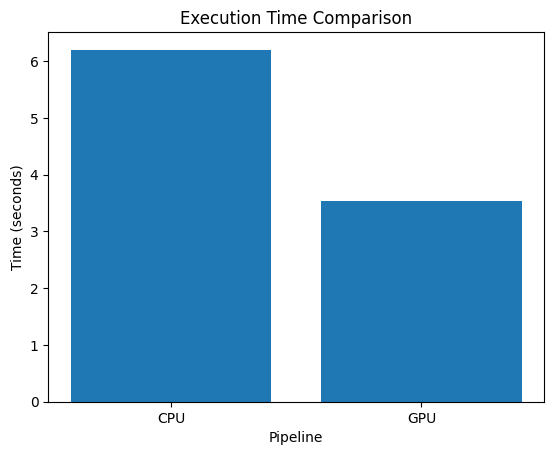

In [3]:
plt.figure()
plt.bar(["CPU", "GPU"], [cpu_time, gpu_time])
plt.title("Execution Time Comparison")
plt.xlabel("Pipeline")
plt.ylabel("Time (seconds)")
plt.show()

In [6]:
'''GPU decoding with nvJPEG is faster because the GPU processes multiple pixels at once using parallel
cores. It’s mpst efficient when the whole pipeline stays on the
GPU, avoiding extra data transfers.

The advantage drops for small datasets or low resolution images.
Frequent CPU-GPU transfers or poor GPU usage may reduce the speed benefit.'''

'GPU decoding with nvJPEG is faster because the GPU processes multiple pixels at once using parallel \ncores. It’s mpst efficient when the whole pipeline stays on the\nGPU, avoiding extra data transfers.\n\nThe advantage drops for small datasets or low resolution images. \nFrequent CPU-GPU transfers or poor GPU usage may reduce the speed benefit.'

Q2 Implement a program that:

• Uses nvJPEG to decode a JPEG image

• Generates two grayscale outputs:
1. Direct grayscale conversion after decoding
2. Manually computed grayscale from RGB channels

• Perform this experiment on two different image resolutions.

• Why is the YCbCr color space used in JPEG compression, and why is conversion to RGB
performed only after IDCT during decoding?

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

class DecodePipeline(Pipeline):
    def __init__(self, image_path):
        super(DecodePipeline, self).__init__(batch_size=1, num_threads=2, device_id=0)
        self.image_path = image_path

    def define_graph(self):
        images, _ = fn.readers.file(files=[self.image_path])
        images = fn.decoders.image(images, device="mixed")
        return images

def decode_nvjpeg(image_path):
    pipe = DecodePipeline(image_path)
    pipe.build()

    output = pipe.run()
    img = output[0].as_cpu().as_array()[0]

    return img

def direct_grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def manual_grayscale(img):
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    return gray.astype(np.uint8)

image1 = "jpeg_dataset/bruno-guerrero-1Ef9P85_JPg-unsplash.jpg"
image2 = "jpeg_dataset/bruno-guerrero-Ugb9Gaccxys-unsplash.jpg"

img1 = decode_nvjpeg(image1)
img2 = decode_nvjpeg(image2)

g1_direct = direct_grayscale(img1)
g1_manual = manual_grayscale(img1)

g2_direct = direct_grayscale(img2)
g2_manual = manual_grayscale(img2)

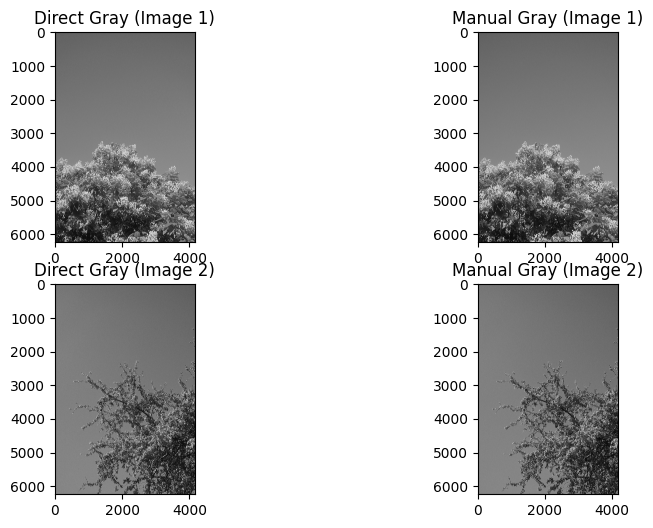

In [9]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.title("Direct Gray (Image 1)")
plt.imshow(g1_direct, cmap='gray')

plt.subplot(2,2,2)
plt.title("Manual Gray (Image 1)")
plt.imshow(g1_manual, cmap='gray')

plt.subplot(2,2,3)
plt.title("Direct Gray (Image 2)")
plt.imshow(g2_direct, cmap='gray')

plt.subplot(2,2,4)
plt.title("Manual Gray (Image 2)")
plt.imshow(g2_manual, cmap='gray')

plt.show()

In [10]:
'''YCbCr is used in JPEG because it separates brightness (Y) from color (Cb, Cr). Human eye is
more sensitive to brightness than color, so we can reduce color detail without much visible quality
loss, giving better compression.

RGB conversion is done after IDCT because JPEG data is stored in the frequency domain. IDCT first
calculates the actual pixel values, and only then can those values be correctly converted into RGB
format. '''

'YCbCr is used in JPEG because it separates brightness (Y) from color (Cb, Cr). Human eye is\nmore sensitive to brightness than color, so we can reduce color detail without much visible quality\nloss, giving better compression.\n\nRGB conversion is done after IDCT because JPEG data is stored in the frequency domain. IDCT first\ncalculates the actual pixel values, and only then can those values be correctly converted into RGB \nformat. '

Q3 Design and compare two preprocessing pipelines:

1.Pipeline A (Hybrid Approach)

1.  Decode images using OpenCV (CPU)

2. Transfer images to GPU

3.  Perform resizing and normalization using CUDA/CuPy/PyTorch

2.Pipeline B (DALI-Based Approach)

1. Use NVIDIA DALI for image loading

2. Perform GPU-based decoding (nvJPEG internally)

3. Apply resizing and normalization on GPU

• Use a dataset of at least 20 images and experiment with different batch sizes and
image resolutions. Measure total execution time for both pipelines

• Compute throughput (images per second)

• Compare efficiency and resource utilization

• Present results using tables/graphs

In [12]:
import os
import cv2
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

import torchvision.transforms.functional as TF

from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn

image_folder = "jpeg_dataset/"
image_paths = [os.path.join(image_folder, img) for img in os.listdir(image_folder) if img.endswith(".jpg")]

print("Total images:", len(image_paths))

def pipeline_A(image_paths, batch_size=1, resize=(512,512)):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    start_time = time.time()

    for i in range(0, len(image_paths), batch_size):
        batch = image_paths[i:i+batch_size]

        imgs = []
        for path in batch:
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, resize)  # ✅ FIX: resize BEFORE stacking

            img = torch.from_numpy(img).permute(2,0,1).float()
            imgs.append(img)

        imgs = torch.stack(imgs).to(device)

        imgs = imgs / 255.0

    total_time = time.time() - start_time
    return total_time


class DALIPipeline(Pipeline):
    def __init__(self, image_paths, batch_size, device_id=0):
        super(DALIPipeline, self).__init__(batch_size, num_threads=2, device_id=device_id)
        self.input = fn.readers.file(files=image_paths, random_shuffle=False)

    def define_graph(self):
        images, _ = self.input

        images = fn.decoders.image(images, device="mixed")  # nvJPEG
        images = fn.resize(images, resize_x=512, resize_y=512)
        images = fn.crop_mirror_normalize(images)

        return images

def pipeline_B(image_paths, batch_size=1):
    pipe = DALIPipeline(image_paths, batch_size=batch_size)
    pipe.build()

    start_time = time.time()

    for _ in range(len(image_paths)//batch_size):
        pipe.run()

    total_time = time.time() - start_time
    return total_time


batch_sizes = [1, 2, 4, 8]

results = []

for b in batch_sizes:
    tA = pipeline_A(image_paths, batch_size=b)
    tB = pipeline_B(image_paths, batch_size=b)

    throughput_A = len(image_paths) / tA
    throughput_B = len(image_paths) / tB

    results.append((b, tA, tB, throughput_A, throughput_B))

results

Total images: 15


[(1,
  6.04608678817749,
  3.18204665184021,
  2.4809435467137155,
  4.713947229945654),
 (2,
  5.612621784210205,
  2.088888645172119,
  2.67254779971082,
  7.180851901640759),
 (4,
  6.046138048171997,
  1.8101768493652344,
  2.4809225129312313,
  8.286483171663573),
 (8,
  6.188775539398193,
  1.197568416595459,
  2.4237427750463585,
  12.525380422642717)]

In [13]:
import pandas as pd

df = pd.DataFrame(results, columns=[
    "Batch Size", "Time A", "Time B", "Throughput A", "Throughput B"
])

df

,Batch Size,Time A,Time B,Throughput A,Throughput B
0,1,6.046087,3.182047,2.480944,4.713947
1,2,5.612622,2.088889,2.672548,7.180852
2,4,6.046138,1.810177,2.480923,8.286483
3,8,6.188776,1.197568,2.423743,12.525380


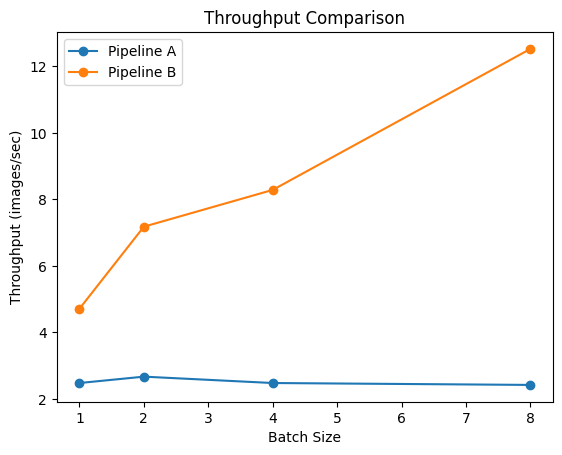

In [14]:
plt.figure()
plt.plot(df["Batch Size"], df["Throughput A"], marker='o', label="Pipeline A")
plt.plot(df["Batch Size"], df["Throughput B"], marker='o', label="Pipeline B")

plt.xlabel("Batch Size")
plt.ylabel("Throughput (images/sec)")
plt.title("Throughput Comparison")
plt.legend()
plt.show()

In [15]:
'''GPU pipelines like DALI + nvJPEG are faster because both decoding and preprocessing
happen directly on the GPU. This avoids CPU bottlenecks and reduces unnecessary data
transfer between CPU and GPU.

They also use parallel processing and combine multiple steps together, which increases
overall throughput and makes the pipeline more efficient. '''

'GPU pipelines like DALI + nvJPEG are faster because both decoding and preprocessing \nhappen directly on the GPU. This avoids CPU bottlenecks and reduces unnecessary data \ntransfer between CPU and GPU.\n\nThey also use parallel processing and combine multiple steps together, which increases \noverall throughput and makes the pipeline more efficient. '